In [50]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [88]:
affected_perimeter_feature_1 = []

In [90]:
affected_perimeter_feature_2 = []

In [92]:
folder_path_affected_fruit = "Dataset/affected"

In [94]:
affected_image_names = [f for f in os.listdir(folder_path_affected_fruit)]

In [96]:
affected_image_names = sorted(affected_image_names)

In [32]:
# masking_lower_bound = np.array([9, 23, 98])
# masking_upper_bound = np.array([224, 234, 243])

In [13]:
# masking_lower_bound = np.array([9, 23, 70])
# masking_upper_bound = np.array([225, 234, 243])

In [62]:
# masking_lower_bound = np.array([0, 0, 94])
# masking_upper_bound = np.array([225, 255, 255])

In [98]:
masking_lower_bound = np.array([0, 0, 46])
masking_upper_bound = np.array([225, 255, 255])

In [100]:
for affected_image_name in affected_image_names:
    affected_image_path = os.path.join(folder_path_affected_fruit, affected_image_name)
    image = cv2.imread(affected_image_path)
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    binary_image = cv2.inRange(hsv_image, masking_lower_bound, masking_upper_bound)
    contours, hierarchy = cv2.findContours(binary_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    sorted_contours = sorted(contours, key=cv2.contourArea, reverse=True)
    if len(sorted_contours) < 2:
        largest_contour = sorted_contours[0]
        affected_perimeter_feature_1.append(cv2.arcLength(largest_contour, True))
        affected_perimeter_feature_2.append(cv2.arcLength(largest_contour, True))
    else:
        largest_contour = sorted_contours[0]
        second_largest_contour = sorted_contours[1]
        affected_perimeter_feature_1.append(cv2.arcLength(second_largest_contour, True))
        sum_of_two_largest_perimeters = cv2.arcLength(largest_contour, True) + cv2.arcLength(second_largest_contour, True)
        affected_perimeter_feature_2.append(sum_of_two_largest_perimeters)

In [102]:
healthy_perimeter_feature_1 = []
healthy_perimeter_feature_2 = []

In [104]:
folder_path_healthy_fruit = "Dataset/healthy"

In [106]:
healthy_image_names = [f for f in os.listdir(folder_path_healthy_fruit)]

In [108]:
for healthy_image_name in healthy_image_names:
    healthy_image_path = os.path.join(folder_path_healthy_fruit, healthy_image_name)
    image = cv2.imread(healthy_image_path)
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    binary_image = cv2.inRange(hsv_image, masking_lower_bound, masking_upper_bound)
    contours, hierarchy = cv2.findContours(binary_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    sorted_contours = sorted(contours, key=cv2.contourArea, reverse=True)
    if len(sorted_contours) < 2:
        largest_contour = sorted_contours[0]
        healthy_perimeter_feature_1.append(cv2.arcLength(largest_contour, True))
        healthy_perimeter_feature_2.append(cv2.arcLength(largest_contour, True))
    else:
        largest_contour = sorted_contours[0]
        second_largest_contour = sorted_contours[1]
        healthy_perimeter_feature_1.append(cv2.arcLength(second_largest_contour, True))
        sum_of_two_largest_perimeters = cv2.arcLength(largest_contour, True) + cv2.arcLength(second_largest_contour, True)
        healthy_perimeter_feature_2.append(sum_of_two_largest_perimeters)

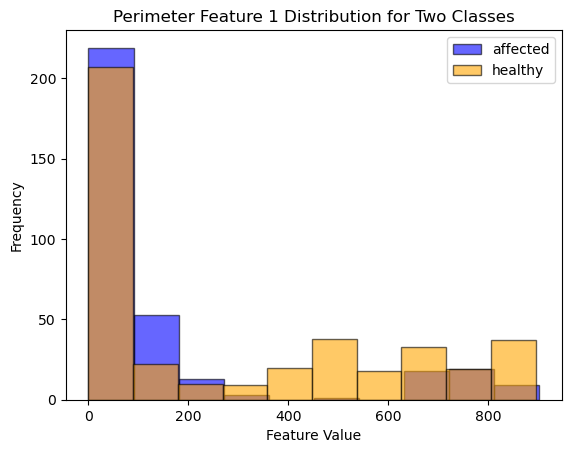

In [110]:
# boundaries
# masking_lower_bound = np.array([0, 0, 46])
# masking_upper_bound = np.array([225, 255, 255])

# Plot histograms
plt.hist(affected_perimeter_feature_1, bins=10, alpha=0.6, label='affected', color='blue', edgecolor='black')
plt.hist(healthy_perimeter_feature_1, bins=10, alpha=0.6, label='healthy', color='orange', edgecolor='black')

# Add labels and legend
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.title('Perimeter Feature 1 Distribution for Two Classes')
plt.legend()

plt.show()

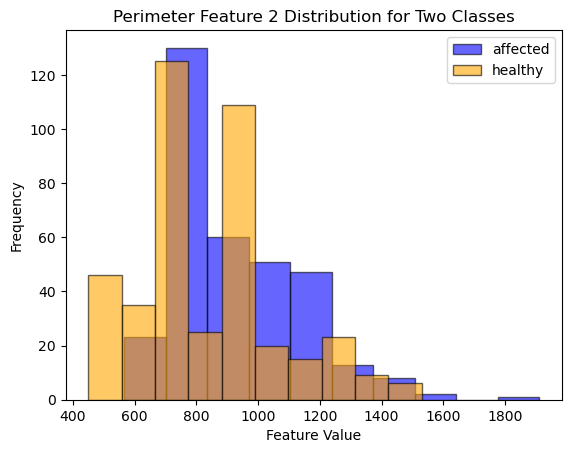

In [112]:
# boundaries
# masking_lower_bound = np.array([0, 0, 46])
# masking_upper_bound = np.array([225, 255, 255])

# Plot histograms
plt.hist(affected_perimeter_feature_2, bins=10, alpha=0.6, label='affected', color='blue', edgecolor='black')
plt.hist(healthy_perimeter_feature_2, bins=10, alpha=0.6, label='healthy', color='orange', edgecolor='black')

# Add labels and legend
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.title('Perimeter Feature 2 Distribution for Two Classes')
plt.legend()

plt.show()

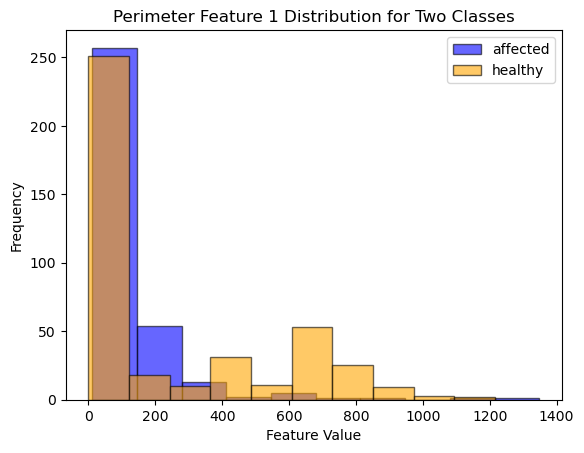

In [82]:
# boundaries
# masking_lower_bound = np.array([0, 0, 94])
# masking_upper_bound = np.array([225, 255, 255])

# Plot histograms
plt.hist(affected_perimeter_feature_1, bins=10, alpha=0.6, label='affected', color='blue', edgecolor='black')
plt.hist(healthy_perimeter_feature_1, bins=10, alpha=0.6, label='healthy', color='orange', edgecolor='black')

# Add labels and legend
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.title('Perimeter Feature 1 Distribution for Two Classes')
plt.legend()

plt.show()

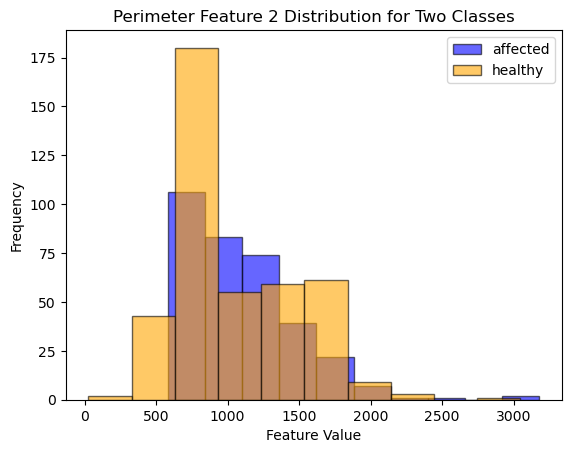

In [84]:
# boundaries
# masking_lower_bound = np.array([0, 0, 94])
# masking_upper_bound = np.array([225, 255, 255])

# Plot histograms
plt.hist(affected_perimeter_feature_2, bins=10, alpha=0.6, label='affected', color='blue', edgecolor='black')
plt.hist(healthy_perimeter_feature_2, bins=10, alpha=0.6, label='healthy', color='orange', edgecolor='black')

# Add labels and legend
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.title('Perimeter Feature 2 Distribution for Two Classes')
plt.legend()

plt.show()

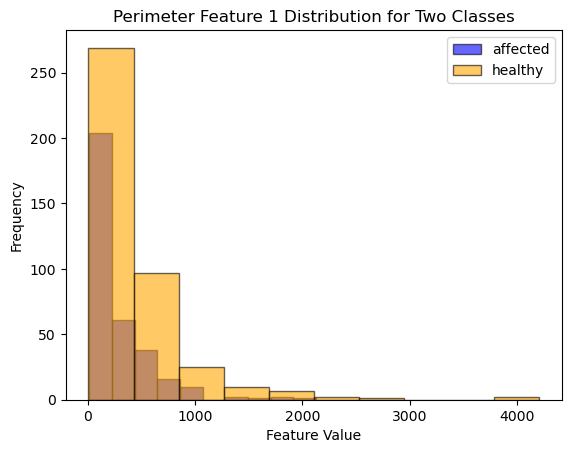

In [25]:
# boundaries
# masking_lower_bound = np.array([9, 23, 70])
# masking_upper_bound = np.array([225, 234, 243])

# Plot histograms
plt.hist(affected_perimeter_feature_1, bins=10, alpha=0.6, label='affected', color='blue', edgecolor='black')
plt.hist(healthy_perimeter_feature_1, bins=10, alpha=0.6, label='healthy', color='orange', edgecolor='black')

# Add labels and legend
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.title('Perimeter Feature 1 Distribution for Two Classes')
plt.legend()

plt.show()

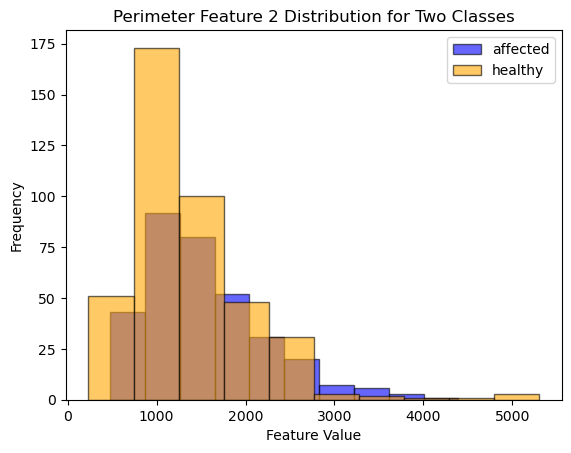

In [27]:
# boundaries
# masking_lower_bound = np.array([9, 23, 70])
# masking_upper_bound = np.array([225, 234, 243])

# Plot histograms
plt.hist(affected_perimeter_feature_2, bins=10, alpha=0.6, label='affected', color='blue', edgecolor='black')
plt.hist(healthy_perimeter_feature_2, bins=10, alpha=0.6, label='healthy', color='orange', edgecolor='black')

# Add labels and legend
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.title('Perimeter Feature 2 Distribution for Two Classes')
plt.legend()

plt.show()

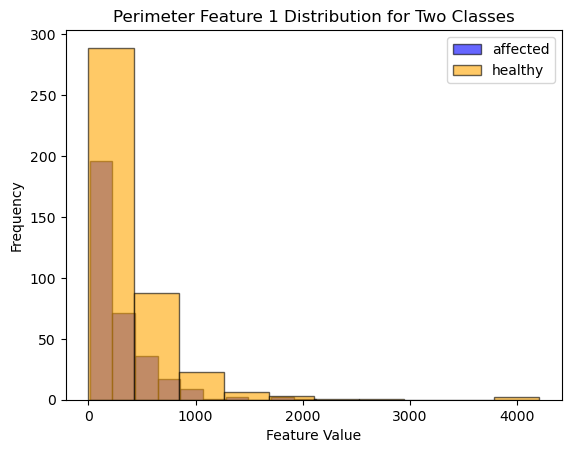

In [50]:
# boundaries
# masking_lower_bound = np.array([9, 23, 98])
# masking_upper_bound = np.array([224, 234, 243])

# Plot histograms
plt.hist(affected_perimeter_feature_1, bins=10, alpha=0.6, label='affected', color='blue', edgecolor='black')
plt.hist(healthy_perimeter_feature_1, bins=10, alpha=0.6, label='healthy', color='orange', edgecolor='black')

# Add labels and legend
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.title('Perimeter Feature 1 Distribution for Two Classes')
plt.legend()

plt.show()

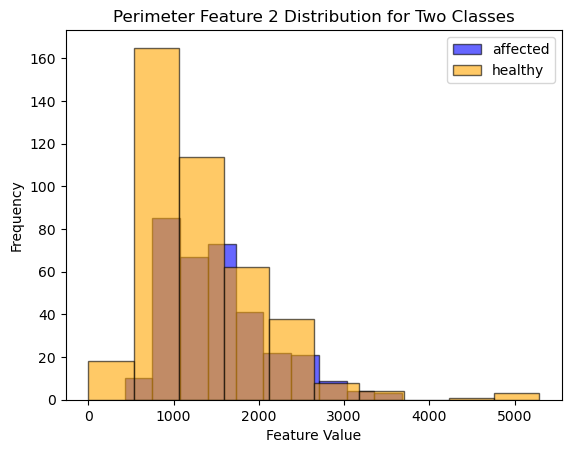

In [52]:
# boundaries
# masking_lower_bound = np.array([9, 23, 98])
# masking_upper_bound = np.array([224, 234, 243])

# Plot histograms
plt.hist(affected_perimeter_feature_2, bins=10, alpha=0.6, label='affected', color='blue', edgecolor='black')
plt.hist(healthy_perimeter_feature_2, bins=10, alpha=0.6, label='healthy', color='orange', edgecolor='black')

# Add labels and legend
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.title('Perimeter Feature 2 Distribution for Two Classes')
plt.legend()

plt.show()